In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install thop
!pip install ptflops
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.7 MB/s eta 0:00:00


In [ ]:
!pip install basicsr facexlib realesrgan


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 18.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 130.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 25.2 MB/s eta 0:00:00
  Created wheel for basicsr: filename=basicsr-1.4.2-py3-none-any.whl size=214819 sha256=e3862f180f66f63b9489fb6c0d56f09b9dd78bb9d27d44d06ca350a93dfd49a9
  Stored in directory: /root/.cache/pip/wheels/9a/e3/e4/58f29bfabb622dd40b6d9839318ce5bf092062b81ca3aa19ea
  Created wheel for 

In [ ]:
import sys
from pathlib import Path

# Path to your LDL repo root
LDL_ROOT = Path("/content/drive/MyDrive/LDL")

# Add it to Python search path
sys.path.append(str(LDL_ROOT))

print("Current sys.path includes:", LDL_ROOT)


Current sys.path includes: /content/drive/MyDrive/LDL


In [ ]:
from pathlib import Path
import os
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt

from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import lpips  # pip install lpips
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------------
# BASE FOLDER: your LDL repo
# ------------------------------------------------------------------
BASE_DIR = Path("/content/drive/MyDrive/LDL")

# ------------------------------------------------------------------
# DATA FOLDERS  (ADJUST to your structure)
# ------------------------------------------------------------------
# Example: if you generated UC Merced LR/HR inside datasets/UCM
HR_DIR = BASE_DIR / "datasets" / "UCM" / "test_HR"      # 256×256 HR
LR_DIR = BASE_DIR / "datasets" / "UCM" / "test_LR_bicx4"  # 64×64 LR (bicubic downsampled)

# ------------------------------------------------------------------
# RESULTS / INTERMEDIATE SR OUTPUTS (MAD curves & qualitative)
# ------------------------------------------------------------------
RESULTS_DIR = BASE_DIR / "results"     # you can change if needed

# ------------------------------------------------------------------
# MODEL CHECKPOINTS for ablations (ADJUST to your experiment names)
# ------------------------------------------------------------------
# Example if you followed LDL repo style: experiments/<exp_name>/models/net_g_latest.pth
CKPT_ESRGAN      = BASE_DIR / "experiments" / "UCM_ESRGAN_x4" / "models" / "net_g_latest.pth"
CKPT_ESRGAN_M    = BASE_DIR / "experiments" / "UCM_ESRGAN_M_x4" / "models" / "net_g_latest.pth"
CKPT_ESRGAN_sigM = BASE_DIR / "experiments" / "UCM_ESRGAN_sigM_x4" / "models" / "net_g_latest.pth"
CKPT_ESRGAN_Mref = BASE_DIR / "experiments" / "UCM_ESRGAN_Mref_x4" / "models" / "net_g_latest.pth"
CKPT_LDL_FULL    = BASE_DIR / "experiments" / "LDL_UCMerced_50k" / "models" / "net_g_latest.pth"

# If you don’t have the partial ablation models, just comment them out
# and only use ESRGAN + LDL_FULL in the ablation.

# LPIPS model
lpips_vgg = lpips.LPIPS(net='vgg').to(device)

to_tensor = transforms.ToTensor()
to_pil = transforms.ToPILImage()


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 164MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


In [ ]:
!pip install basicsr facexlib realesrgan

In [ ]:
%cd /content/drive/MyDrive/LDL


/content/drive/MyDrive/LDL


In [ ]:
%cd /content/drive/MyDrive/LDL
!python train_esrgan_ablation.py --variant M --iters 20000

/content/drive/MyDrive/LDL
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
[Dataset] Loaded 1470 HR–LR pairs.
[M] Iter 000100 D: 0.2457  G: 1.3649  L_artif: 0.0011
[M] Iter 000200 D: 0.2049  G: 1.4511  L_artif: 0.0009
[M] Iter 000300 D: 0.1994  G: 1.5996  L_artif: 0.0015
[M] Iter 000400 D: 0.2464  G: 1.4996  L_artif: 0.0008
[M] Iter 000500 D: 0.2441  G: 1.6751  L_artif: 0.0018
[M] Iter 000600 D: 0.1961  G: 1.7712  L_artif: 0.0022
[M] Iter 000700 D: 0.1907  G: 1.9525  L_artif: 0.0034
[M] Iter 000800 D: 0.2008  G: 1.5963  L_artif: 0.0004
[M] Iter 000900 D: 0.2018  G: 1.8843  L_artif: 0.0026
[M] Iter 001000 D: 0.2461  G: 1.5749  L_artif: 0.0035
[M] Iter 001100 D: 0.2543  G: 1.4117  L_artif: 0.0007
[M] Iter 001200 D: 0.1907  G: 1.5129  L_artif: 0.0012
[M] Iter 001300

In [ ]:
!python train_esrgan_ablation.py --variant sigmaM --iters 10000

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
[Dataset] Loaded 1470 HR–LR pairs.
[sigmaM] Iter 000100 D: 0.2608  G: 1.5047  L_artif: 0.0003
Traceback (most recent call last):
  File "/content/drive/MyDrive/LDL/train_esrgan_ablation.py", line 392, in <module>
    train_variant(variant=args.variant, exp_name=exp, num_iters=args.iters)
  File "/content/drive/MyDrive/LDL/train_esrgan_ablation.py", line 345, in train_variant
    loss_g.backward()
  File "/usr/local/lib/python3.12/dist-packages/torch/_tensor.py", line 625, in backward
    torch.autograd.backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/__init__.py", line 354, in backward
    _engine_run_backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py", line 841

In [ ]:
!python train_esrgan_ablation.py --variant Mrefine --iters 10000

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
[Dataset] Loaded 1470 HR–LR pairs.
[Mrefine] Iter 000100 D: 0.2540  G: 1.6626  L_artif: 0.0004
[Mrefine] Iter 000200 D: 0.2177  G: 1.5423  L_artif: 0.0005
[Mrefine] Iter 000300 D: 0.2247  G: 1.7203  L_artif: 0.0004
[Mrefine] Iter 000400 D: 0.1853  G: 1.5864  L_artif: 0.0021
[Mrefine] Iter 000500 D: 0.2422  G: 1.5094  L_artif: 0.0045
[Mrefine] Iter 000600 D: 0.1677  G: 1.6055  L_artif: 0.0002
[Mrefine] Iter 000700 D: 0.1930  G: 1.6821  L_artif: 0.0002
[Mrefine] Iter 000800 D: 0.2195  G: 1.2852  L_artif: 0.0001
[Mrefine] Iter 000900 D: 0.2588  G: 1.5550  L_artif: 0.0009
[Mrefine] Iter 001000 D: 0.2208  G: 1.3411  L_artif: 0.0005
[Mrefine] Iter 001100 D: 0.2092  G: 1.5706  L_artif: 0.0004
[Mrefine] Iter 001200 D: 0.255

In [ ]:
import sys
from pathlib import Path
BASE_DIR = Path("/content/drive/MyDrive/LDL")

CKPT_ESRGAN_M      = BASE_DIR / "experiments" / "UCM_ESRGAN_M_x4" / "models" / "net_g_iter_10000.pth"
CKPT_ESRGAN_sigM   = BASE_DIR / "experiments" / "UCM_ESRGAN_sigmaM_x4" / "models" / "net_g_iter_7000.pth"
CKPT_ESRGAN_Mref   = BASE_DIR / "experiments" / "UCM_ESRGAN_Mref_x4" / "models" / "net_g_iter_10000.pth"

# Also add your ESRGAN baseline and full LDL if needed
CKPT_ESRGAN_BASE   = BASE_DIR / "experiments" / "ESRGAN_UCMerced_x4" / "models" / "net_g_latest.pth"
CKPT_LDL_FULL      = BASE_DIR / "experiments" / "LDL_UCMerced_50k" / "models" / "net_g_latest.pth"


In [ ]:
import torch
import numpy as np
from pathlib import Path
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from torchvision import transforms
import lpips

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------
# 1. Import RRDBNet (same as training)
# ----------------------------
try:
    from basicsr.models.archs.rrdbnet_arch import RRDBNet
    print("Imported RRDBNet from basicsr.models.archs")
except Exception:
    from basicsr.archs.rrdbnet_arch import RRDBNet
    print("Imported RRDBNet from basicsr.archs")


# ----------------------------
# 2. Universal model loader
# ----------------------------
def load_model(ckpt_path):
    """Load RRDBNet from a checkpoint, trying multiple common keys."""
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    print("\nLoading checkpoint:", ckpt_path)
    model = RRDBNet(
        num_in_ch=3, num_out_ch=3,
        num_feat=64, num_block=23,
        num_grow_ch=32, scale=4
    ).to(device)

    ckpt = torch.load(ckpt_path, map_location=device)

    # Keys commonly used in ESRGAN / LDL / our script
    possible_keys = [
        "params_ema",   # EMA weights (often used in LDL)
        "params",       # your baseline ESRGAN uses this
        "state_dict",   # our ablation training script uses this
        "model",
        "net_g",
        "network_g",
        "state_dict_g",
    ]

    found = None
    for k in possible_keys:
        if k in ckpt:
            found = k
            print(f"  → Found weights under key: '{k}'")
            state_dict = ckpt[k]
            model.load_state_dict(state_dict, strict=False)
            break

    if found is None:
        # Last fallback: checkpoint itself might be the state dict
        print("  → No known key found. Trying to load entire checkpoint as state_dict...")
        try:
            model.load_state_dict(ckpt, strict=False)
            found = "direct"
        except Exception as e:
            print("Available keys:", ckpt.keys())
            raise ValueError(f"Cannot load weights from checkpoint: {e}")

    model.eval()
    return model


# ----------------------------
# 3. Metrics: PSNR / SSIM / LPIPS
# ----------------------------
to_tensor = transforms.ToTensor()
lpips_fn = lpips.LPIPS(net='vgg').to(device)

def rgb_to_y(img):
    """Convert RGB [0,1] float image to Y channel."""
    r, g, b = img[..., 0], img[..., 1], img[..., 2]
    return 0.257 * r + 0.504 * g + 0.098 * b + 0.0625

def evaluate_model(model, hr_dir, lr_dir):
    hr_dir = Path(hr_dir)
    lr_dir = Path(lr_dir)

    psnr_list, ssim_list, lpips_list = [], [], []

    # Accept any extension in HR folder
    hr_files = sorted(list(hr_dir.glob("*.tif")) +
                      list(hr_dir.glob("*.png")) +
                      list(hr_dir.glob("*.jpg")) +
                      list(hr_dir.glob("*.jpeg")))

    print(f"  → Found {len(hr_files)} HR images for evaluation.")

    for hr_path in hr_files:
        lr_path = lr_dir / hr_path.name
        if not lr_path.exists():
            # if LR ext is different (e.g., .png vs .tif), adjust here
            # lr_path = lr_dir / (hr_path.stem + ".png")
            # if not lr_path.exists():
            #     continue
            continue

        hr = Image.open(hr_path).convert("RGB")
        lr = Image.open(lr_path).convert("RGB")

        # SR inference
        with torch.no_grad():
            lr_t = to_tensor(lr).unsqueeze(0).to(device)  # [1,3,h,w]
            sr_t = model(lr_t)
            sr_t = torch.clamp(sr_t, 0, 1)
        sr = sr_t.squeeze(0).cpu().permute(1, 2, 0).numpy()  # [H,W,3], float32

        # HR numpy
        hr_np = np.array(hr).astype(np.float32) / 255.0

        # --- PSNR & SSIM on Y channel ---
        hr_y = rgb_to_y(hr_np)
        sr_y = rgb_to_y(sr)
        psnr = peak_signal_noise_ratio(hr_y, sr_y, data_range=1.0)
        ssim = structural_similarity(hr_y, sr_y, data_range=1.0)

        psnr_list.append(psnr)
        ssim_list.append(ssim)

        # --- LPIPS ---
        with torch.no_grad():
            hr_tt = to_tensor(hr).unsqueeze(0).to(device)
            sr_tt = torch.from_numpy(sr.transpose(2, 0, 1)).unsqueeze(0).to(device)
            lp = lpips_fn(sr_tt, hr_tt).item()
        lpips_list.append(lp)

    return {
        "PSNR": float(np.mean(psnr_list)),
        "SSIM": float(np.mean(ssim_list)),
        "LPIPS": float(np.mean(lpips_list)),
    }


# ----------------------------
# 4. Paths: checkpoints + test data
# ----------------------------
BASE_DIR = Path("/content/drive/MyDrive/LDL")

# 🔴 TODO: adjust names if needed, based on what is inside each /models folder
CKPT_ESRGAN_BASE = BASE_DIR / "experiments" / "ESRGAN_UCMerced_x4"      / "models" / "net_g_latest.pth"
CKPT_ESRGAN_M    = BASE_DIR / "experiments" / "UCM_ESRGAN_M_x4"         / "models" / "net_g_iter_10000.pth"
CKPT_ESRGAN_sigM = BASE_DIR / "experiments" / "UCM_ESRGAN_sigmaM_x4"    / "models" / "net_g_iter_7000.pth"
CKPT_ESRGAN_Mref = BASE_DIR / "experiments" / "UCM_ESRGAN_Mref_x4"      / "models" / "net_g_iter_10000.pth"
CKPT_LDL_FULL    = BASE_DIR / "experiments" / "LDL_UCMerced_50k"         / "models" / "net_g_latest.pth"

# Test set paths (change if your test split is named differently)
HR_TEST = BASE_DIR / "datasets" / "UCMerced" / "test" / "HR"
LR_TEST = BASE_DIR / "datasets" / "UCMerced" / "test" / "LR_x4"

print("HR_TEST:", HR_TEST)
print("LR_TEST:", LR_TEST)

models = {
    "ESRGAN (baseline)": CKPT_ESRGAN_BASE,
    "ESRGAN + M":        CKPT_ESRGAN_M,
    "ESRGAN + σM":       CKPT_ESRGAN_sigM,
    "ESRGAN + M_refine": CKPT_ESRGAN_Mref,
    "LDL-SR (full)":     CKPT_LDL_FULL,
}

# ----------------------------
# 5. Run evaluation for all models
# ----------------------------
results = {}
for name, ckpt in models.items():
    if not ckpt.exists():
        print(f"\n⚠️ Skipping {name}, checkpoint not found: {ckpt}")
        continue

    print(f"\nEvaluating: {name}")
    model = load_model(ckpt)
    res = evaluate_model(model, HR_TEST, LR_TEST)
    results[name] = res
    print("  → Result:", res)

# ----------------------------
# 6. Print report-style table
# ----------------------------
print("\n================ ABLATION RESULTS (UC Merced Test) ================\n")
print(f"{'Model':25s} | {'PSNR':>7s} | {'SSIM':>7s} | {'LPIPS':>7s}")
print("-" * 60)
for name, m in results.items():
    print(f"{name:25s} | {m['PSNR']:.4f} | {m['SSIM']:.4f} | {m['LPIPS']:.44f}")


Using device: cuda
Imported RRDBNet from basicsr.archs
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
HR_TEST: /content/drive/MyDrive/LDL/datasets/UCMerced/test/HR
LR_TEST: /content/drive/MyDrive/LDL/datasets/UCMerced/test/LR_x4

Evaluating: ESRGAN (baseline)

Loading checkpoint: /content/drive/MyDrive/LDL/experiments/ESRGAN_UCMerced_x4/models/net_g_latest.pth
  → Found weights under key: 'params'
  → Found 420 HR images for evaluation.
  → Result: {'PSNR': 21.945522561880864, 'SSIM': 0.5649925896466382, 'LPIPS': 0.3606974378582977}

Evaluating: ESRGAN + M

Loading checkpoint: /content/drive/MyDrive/LDL/experiments/UCM_ESRGAN_M_x4/models/net_g_iter_10000.pth
  → Found weights under key: 'state_dict'
  → Found 420 HR images for evaluation.
  → Result: {'PSNR': 21.052751768062574, 'SSIM': 0.4714744376005862, 'LPIPS': 0.4434675714799336}

Evaluating: ESRGAN + σM

Loading checkpoi

In [ ]:
import torch
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

Type A / B / C Region Analysis (Patch-Level)


Loading checkpoint: /content/drive/MyDrive/LDL/experiments/ESRGAN_UCMerced_x4/models/net_g_latest.pth
  → Found weights under key: 'params'

Loading checkpoint: /content/drive/MyDrive/LDL/experiments/LDL_UCMerced_50k/models/net_g_latest.pth
  → Found weights under key: 'params_ema'


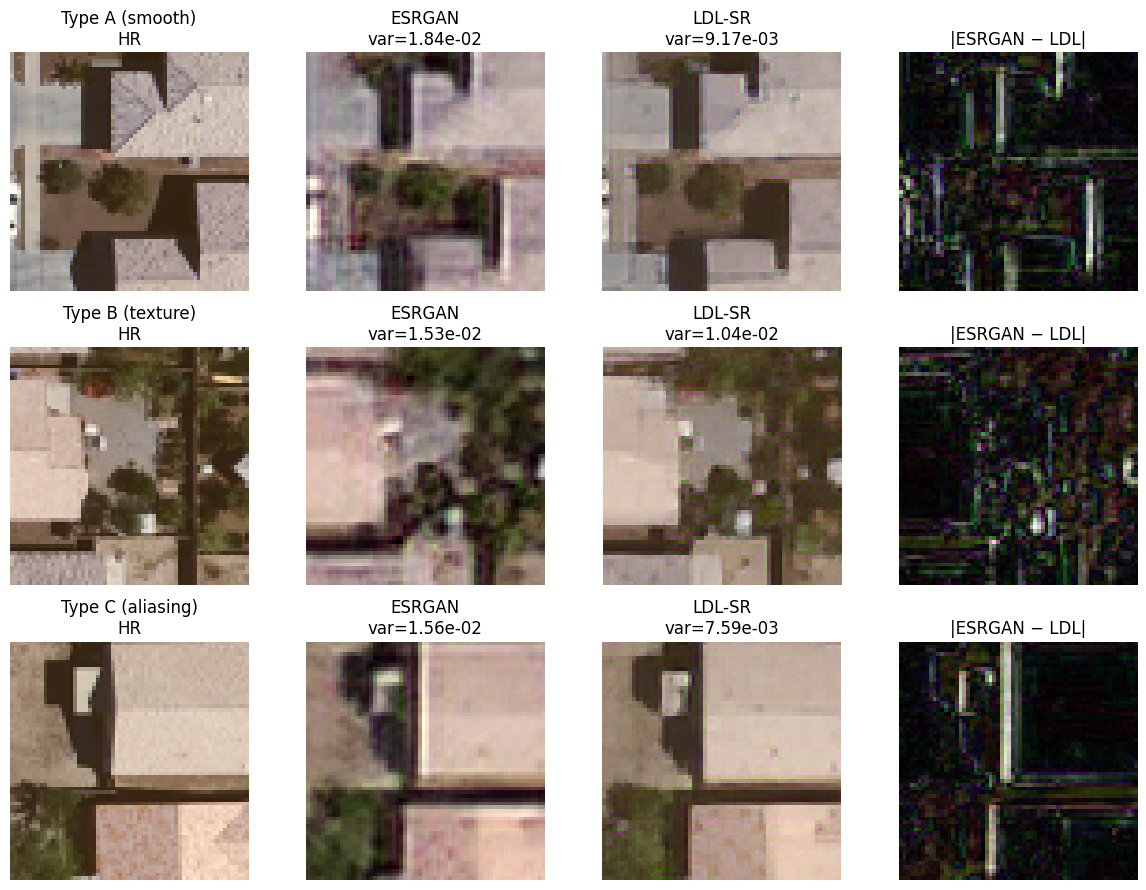

In [ ]:
# Load models
import matplotlib.pyplot as plt
esrgan = load_model(CKPT_ESRGAN_BASE)
ldl    = load_model(CKPT_LDL_FULL)

# Choose a test image
IMG_NAME = "denseresidential_denseresidential96.png"  # <-- change to one that exists in HR_TEST

hr_path = HR_TEST / IMG_NAME
lr_path = LR_TEST / IMG_NAME

hr_img = Image.open(hr_path).convert("RGB")
lr_img = Image.open(lr_path).convert("RGB")

# SR outputs
with torch.no_grad():
    lr_t = to_tensor(lr_img).unsqueeze(0).to(device)
    sr_esr_t = esrgan(lr_t)
    sr_ldl_t = ldl(lr_t)
    sr_esr_t = torch.clamp(sr_esr_t, 0, 1)
    sr_ldl_t = torch.clamp(sr_ldl_t, 0, 1)

sr_esr = sr_esr_t.squeeze(0).cpu().permute(1,2,0).numpy()
sr_ldl = sr_ldl_t.squeeze(0).cpu().permute(1,2,0).numpy()
hr_np  = np.array(hr_img).astype(np.float32) / 255.0

# ---- MANUALLY PICK PATCHES (x, y, w, h) ----
# You can tweak these after visualizing the image.
patches = {
    "Type A (smooth)":   (10, 10, 64, 64),
    "Type B (texture)":  (80, 80, 64, 64),
    "Type C (aliasing)": (140, 140, 64, 64),
}

def extract_patch(img_np, box):
    x, y, w, h = box
    return img_np[y:y+h, x:x+w, :]

def residual_variance(hr_patch, sr_patch):
    r = hr_patch - sr_patch
    return np.var(r)

fig, axes = plt.subplots(len(patches), 4, figsize=(12, 3 * len(patches)))

for row, (label, box) in enumerate(patches.items()):
    hr_p  = extract_patch(hr_np, box)
    esr_p = extract_patch(sr_esr, box)
    ldl_p = extract_patch(sr_ldl, box)

    v_esr = residual_variance(hr_p, esr_p)
    v_ldl = residual_variance(hr_p, ldl_p)

    axes[row, 0].imshow(hr_p)
    axes[row, 0].set_title(f"{label}\nHR")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(esr_p)
    axes[row, 1].set_title(f"ESRGAN\nvar={v_esr:.2e}")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(ldl_p)
    axes[row, 2].set_title(f"LDL-SR\nvar={v_ldl:.2e}")
    axes[row, 2].axis("off")

    diff = np.abs(esr_p - ldl_p)
    if diff.max() > 0:
        axes[row, 3].imshow(diff / diff.max())
    else:
        axes[row, 3].imshow(diff)
    axes[row, 3].set_title("|ESRGAN − LDL|")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()

More Structured Qualitative Visual Comparisons


Loading checkpoint: /content/drive/MyDrive/LDL/experiments/ESRGAN_UCMerced_x4/models/net_g_latest.pth
  → Found weights under key: 'params'

Loading checkpoint: /content/drive/MyDrive/LDL/experiments/LDL_UCMerced_50k/models/net_g_latest.pth
  → Found weights under key: 'params_ema'


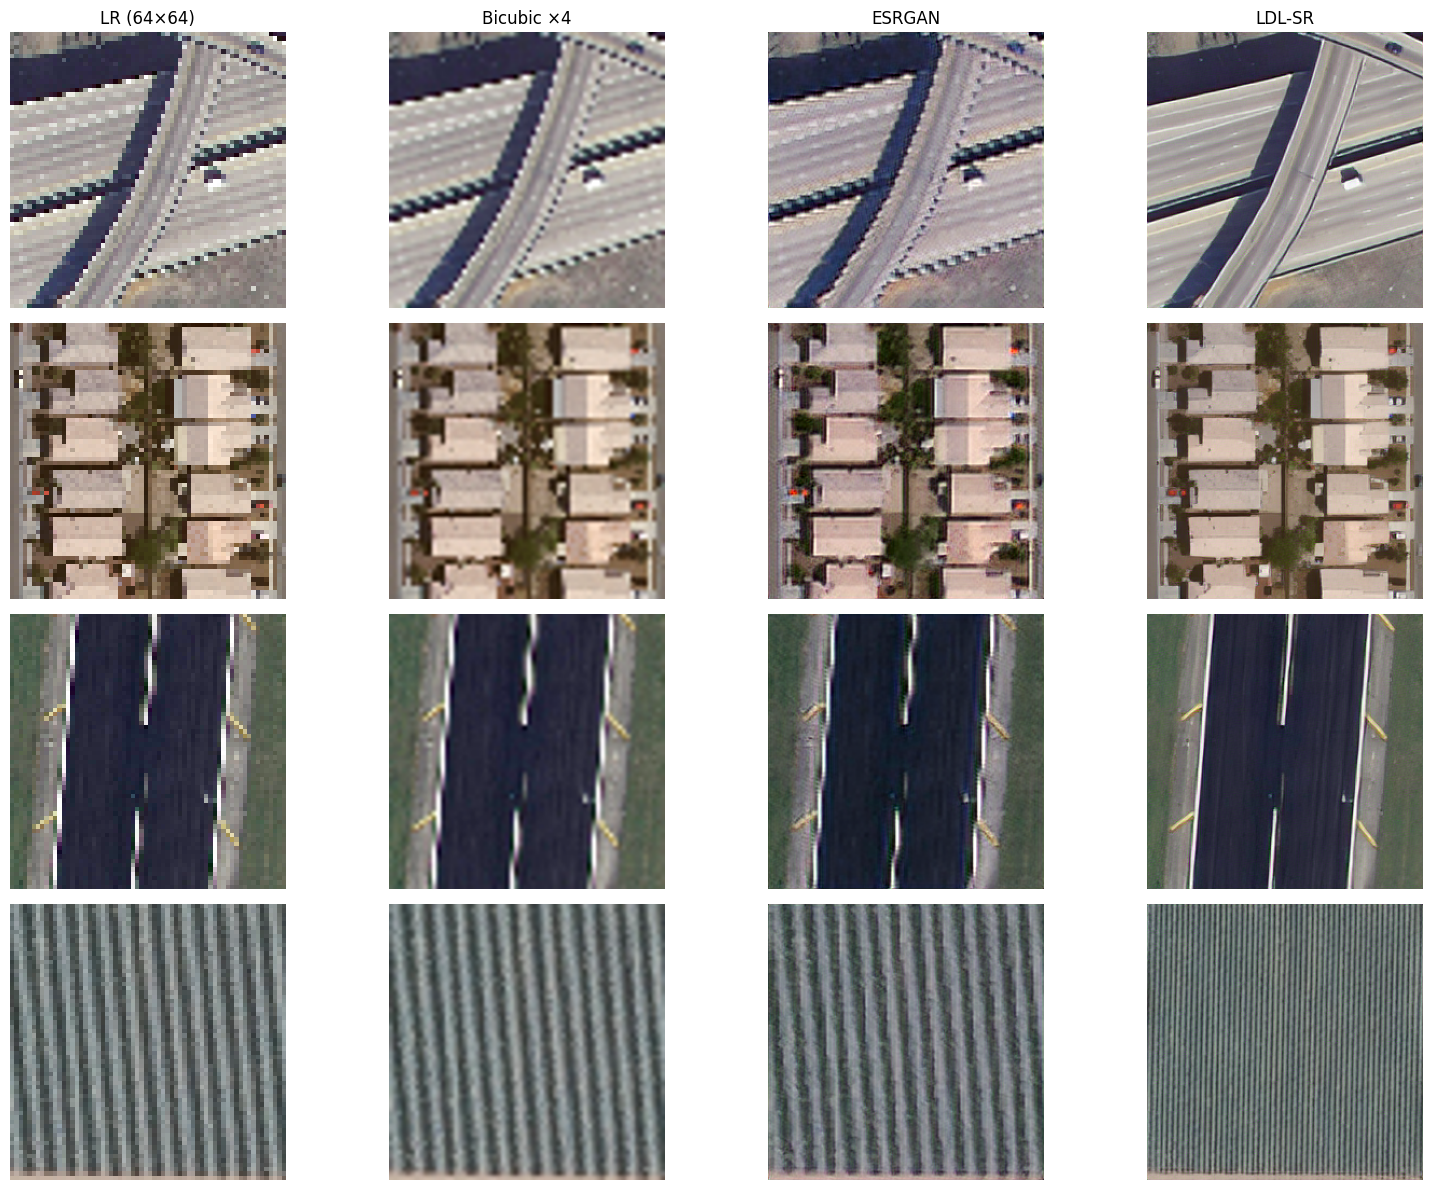

Saved qualitative grid to: /content/drive/MyDrive/LDL/results/ucm_qualitative_grid.png


In [ ]:
def upsample_bicubic(lr_pil, size=(256, 256)):
    return lr_pil.resize(size, Image.BICUBIC)

esrgan = load_model(CKPT_ESRGAN_BASE)
ldl    = load_model(CKPT_LDL_FULL)

# Pick some representative examples
EXAMPLES = [
    "uc_overpass_overpass95.png",
    "denseresidential_denseresidential96.png",
    "runway_runway32.png",
    "agricultural_agricultural70.png",
]  # adjust these names based on what actually exists

n_rows = len(EXAMPLES)
n_cols = 4  # LR, Bicubic, ESRGAN, LDL-SR

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))

for i, name in enumerate(EXAMPLES):
    hr_path = HR_TEST / name
    lr_path = LR_TEST / name
    if not (hr_path.exists() and lr_path.exists()):
        print(f"Skipping {name}, file not found.")
        continue

    lr = Image.open(lr_path).convert("RGB")
    bicubic = upsample_bicubic(lr)

    with torch.no_grad():
        lr_t = to_tensor(lr).unsqueeze(0).to(device)
        sr_esr_t = esrgan(lr_t)
        sr_ldl_t = ldl(lr_t)
        sr_esr_t = torch.clamp(sr_esr_t, 0, 1)
        sr_ldl_t = torch.clamp(sr_ldl_t, 0, 1)

    sr_esr = sr_esr_t.squeeze(0).cpu()
    sr_ldl = sr_ldl_t.squeeze(0).cpu()

    sr_esr_img = transforms.ToPILImage()(sr_esr)
    sr_ldl_img = transforms.ToPILImage()(sr_ldl)

    imgs = [lr, bicubic, sr_esr_img, sr_ldl_img]
    titles = ["LR (64×64)", "Bicubic ×4", "ESRGAN", "LDL-SR"]

    for j in range(n_cols):
        axes[i, j].imshow(imgs[j])
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(titles[j], fontsize=12)

plt.tight_layout()

# Save for report
qual_fig_path = BASE_DIR / "results" / "ucm_qualitative_grid.png"
qual_fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(qual_fig_path, dpi=300)
plt.show()

print("Saved qualitative grid to:", qual_fig_path)


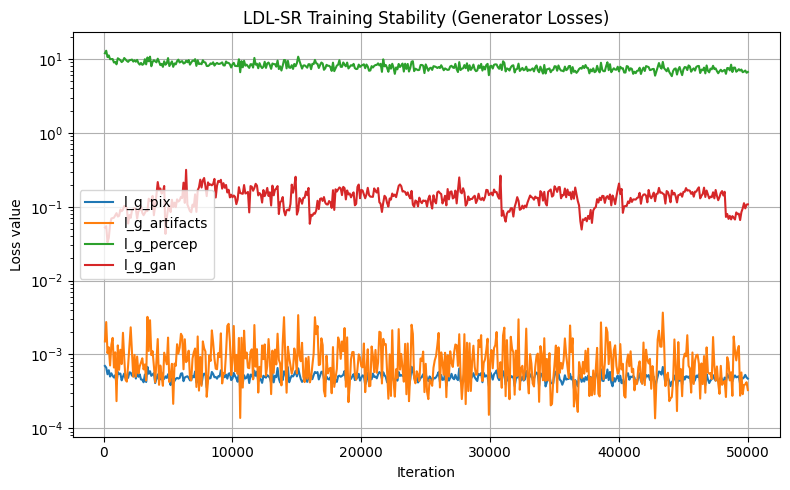

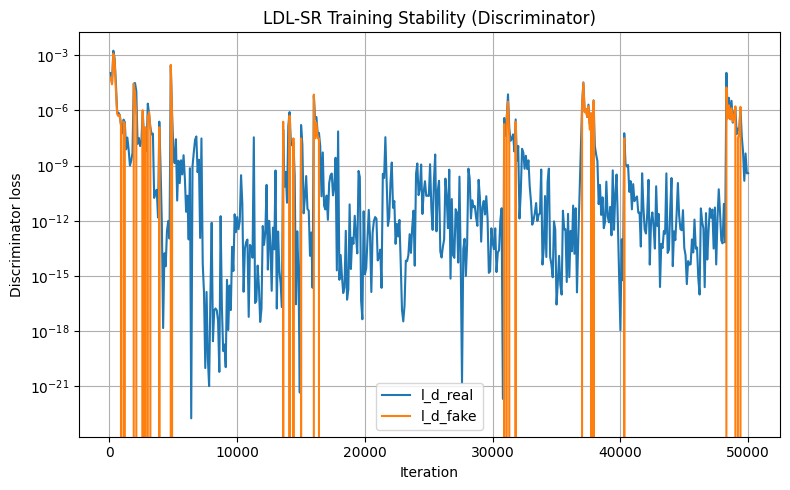

In [5]:
import re
import matplotlib.pyplot as plt

log_path = '/content/drive/MyDrive/LDL/experiments/LDL_UCMerced_50k/train_LDL_UCMerced_50k_20251119_020306.log'

pattern = re.compile(
    r'iter:\s*([0-9,]+).*?'
    r'l_g_pix:\s*([0-9eE\+\-\.]+)\s*'
    r'l_g_artifacts:\s*([0-9eE\+\-\.]+)\s*'
    r'l_g_percep:\s*([0-9eE\+\-\.]+)\s*'
    r'l_g_gan:\s*([0-9eE\+\-\.]+)\s*'
    r'l_d_real:\s*([0-9eE\+\-\.]+)\s*'
    r'l_d_fake:\s*([0-9eE\+\-\.]+)'
)

iters = []
l_g_pix, l_g_art, l_g_percep, l_g_gan = [], [], [], []
l_d_real, l_d_fake = [], []

with open(log_path, 'r') as f:
    for line in f:
        m = pattern.search(line)
        if m:
            it = int(m.group(1).replace(',', ''))
            iters.append(it)
            l_g_pix.append(float(m.group(2)))
            l_g_art.append(float(m.group(3)))
            l_g_percep.append(float(m.group(4)))
            l_g_gan.append(float(m.group(5)))
            l_d_real.append(float(m.group(6)))
            l_d_fake.append(float(m.group(7)))

# --- Plot generator losses (Training Stability figure) ---
plt.figure(figsize=(8,5))
plt.plot(iters, l_g_pix, label='l_g_pix')
plt.plot(iters, l_g_art, label='l_g_artifacts')
plt.plot(iters, l_g_percep, label='l_g_percep')
plt.plot(iters, l_g_gan, label='l_g_gan')
plt.xlabel('Iteration')
plt.ylabel('Loss value')
plt.yscale('log')          # optional but usually looks better
plt.title('LDL-SR Training Stability (Generator Losses)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(8,5))
plt.plot(iters, l_d_real, label='l_d_real')
plt.plot(iters, l_d_fake, label='l_d_fake')
plt.xlabel('Iteration')
plt.ylabel('Discriminator loss')
plt.yscale('log')
plt.title('LDL-SR Training Stability (Discriminator)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


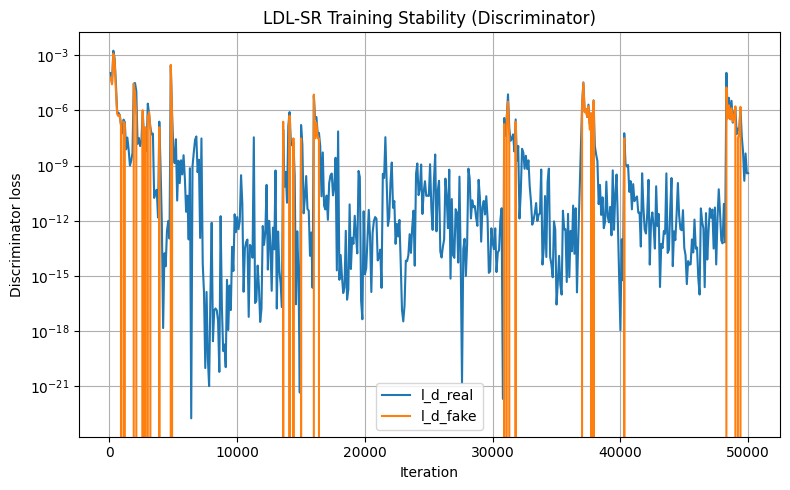

In [4]:
plt.figure(figsize=(8,5))
plt.plot(iters, l_d_real, label='l_d_real')
plt.plot(iters, l_d_fake, label='l_d_fake')
plt.xlabel('Iteration')
plt.ylabel('Discriminator loss')
plt.yscale('log')
plt.title('LDL-SR Training Stability (Discriminator)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


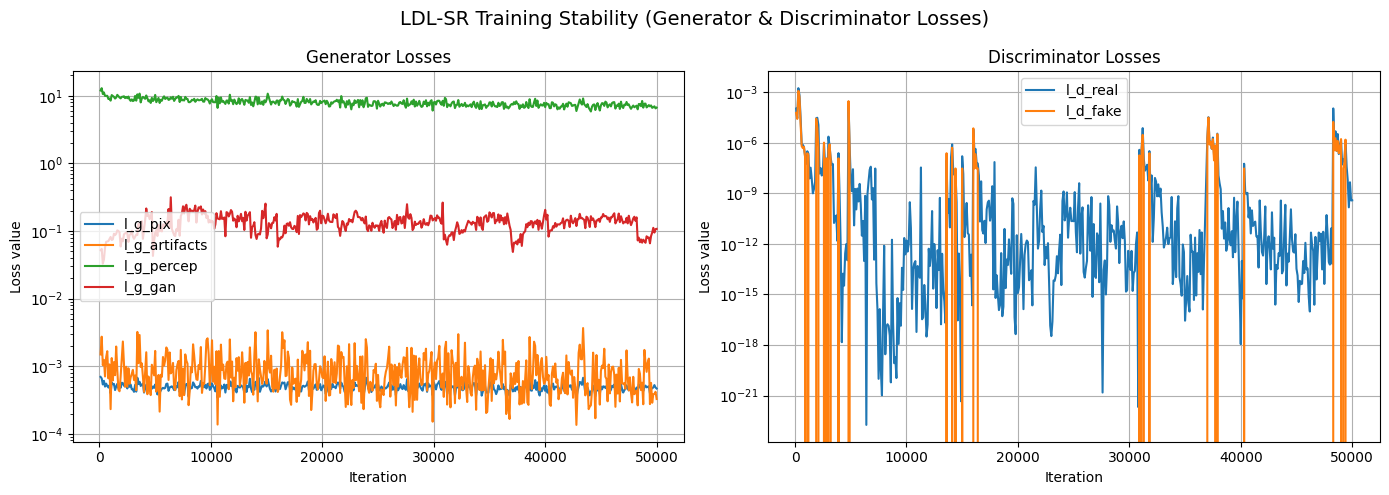

In [6]:
# --- Plot side-by-side losses ---
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ---- Left: Generator losses ----
axes[0].plot(iters, l_g_pix, label='l_g_pix')
axes[0].plot(iters, l_g_art, label='l_g_artifacts')
axes[0].plot(iters, l_g_percep, label='l_g_percep')
axes[0].plot(iters, l_g_gan, label='l_g_gan')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss value')
axes[0].set_yscale('log')
axes[0].set_title('Generator Losses')
axes[0].grid(True)
axes[0].legend()

# ---- Right: Discriminator losses ----
axes[1].plot(iters, l_d_real, label='l_d_real')
axes[1].plot(iters, l_d_fake, label='l_d_fake')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss value')
axes[1].set_yscale('log')
axes[1].set_title('Discriminator Losses')
axes[1].grid(True)
axes[1].legend()

plt.suptitle("LDL-SR Training Stability (Generator & Discriminator Losses)", fontsize=14)
plt.tight_layout()
plt.show()